## 2025-02-12

### Authors
* Nicole Tin (nicole@velexi.com)


### Ideas in this Notebook
* what can we define using CIELAB as a primary colorspace?


### Preparations

In [1]:
# Dataset
dataset_name = "hawkeye-hands"

# AutoML
experiment_name = "2025-01-10_NT_hawkeye-hands-texture"
num_best_models = 5
random_seed = 42

# Paths
root = '/Users/ntin/Documents/DermaML_local/hawkeye-hands-2024-07-29'
# src_dir = '/Users/nicole/Documents/DermaML_local/hawkeye-hands-2024-07-29/processed_images/'
features_dir =  '/Users/ntin/Documents/DermaML_local/hawkeye-hands-2024-07-29/features-2024-08-02/'

image_folder = '/processed_images/'
csv_file = '/metadata.csv'

In [2]:
# --- Imports

# Internal library

# Standard library
import random 
import math
import seaborn as sns
# External packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import cv2

# Entropy
random.seed(42)
np.random.seed(42)

np.set_printoptions(precision=3, suppress=True)

In [3]:
# -- Read the CSV file
metadata = pd.read_csv(root+ csv_file)
metadata.loc[:, 'Age'] = 2024-metadata['birth_year']
valid_image_fnames_df = pd.DataFrame(metadata.set_index('Age').loc[:, ['right_hand_image_file', 'left_hand_image_file']].stack()).reset_index()
valid_image_fnames_df.columns = ['Age', 'handedness', 'filename']
valid_image_fnames_df.loc[:,'filename'] = valid_image_fnames_df['filename'].apply(lambda x: x[:-5])
valid_image_fnames = valid_image_fnames_df['filename'].to_numpy()

In [4]:
texture_features = pd.read_csv('2024-08-01_NT_Hawkeye-Hands-Texture-Features.csv')
# data cleaning and preprocessing
texture_features = texture_features.drop(columns=['Unnamed: 0',])
outliers = texture_features[(texture_features.Age > 200) & texture_features.Age < 3]
texture_features = texture_features.drop(index=outliers.index)
texture_features.loc[:, 'Age'] = np.around(texture_features.loc[:, 'Age']/5, decimals=0)*5

### Read Images

In [5]:
# -- Read Images
sample_image_filenames = os.listdir(root+'/images_sample/')
sample_images = []
for f in sample_image_filenames:
    path = root+'/images_sample/' + f
    sample_images += [plt.imread(path)]

# ds = hub.load('hub://activeloop/11k-hands')
# images = ds.images

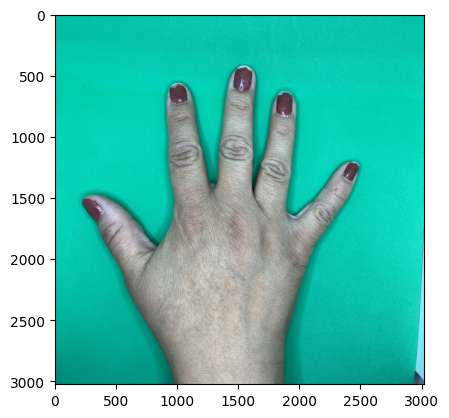

In [6]:
plt.imshow(sample_images[1])

### Relative Intensity in Redness

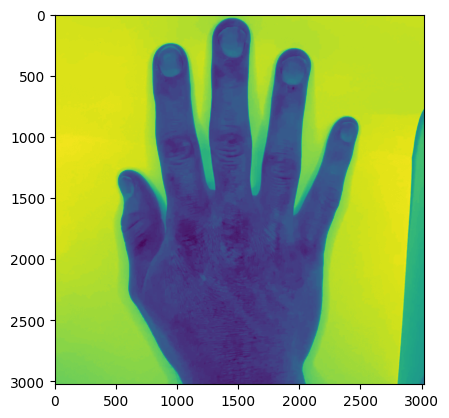

In [7]:
plt.imshow(cv2.cvtColor(sample_images[2], cv2.COLOR_BGR2LAB)[:, :, 2])